In [439]:
import pandas as pd 
import numpy as np 
import matplotlib as plt
import seaborn as sns

In [440]:
nt = pd.read_csv('C:\\Users\\hosse\\Downloads\\Netflix.csv')
nt.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [441]:
nt1 = nt.copy()
nt1.info()
nt1 = nt1[['show_id', 'type', #'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating']] #'duration', 'listed_in', 'description']]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       200 non-null    object
 1   type          200 non-null    object
 2   title         200 non-null    object
 3   director      137 non-null    object
 4   cast          180 non-null    object
 5   country       136 non-null    object
 6   date_added    200 non-null    object
 7   release_year  200 non-null    int64 
 8   rating        200 non-null    object
 9   duration      200 non-null    object
 10  listed_in     200 non-null    object
 11  description   200 non-null    object
dtypes: int64(1), object(11)
memory usage: 18.9+ KB


In [442]:
def rate_label(rating):
    if rating == 'TV':
        return "TV show with number of rating beside"
    elif rating == 'PG':
        return "This movie rated PG"
    else:
        return "Other rating"


In [443]:
nt1

,show_id,type,release_year,rating
0,s1,Movie,2020,PG-13
1,s2,TV Show,2021,TV-MA
2,s3,TV Show,2021,TV-MA
3,s4,TV Show,2021,TV-MA
4,s5,TV Show,2021,TV-MA
...,...,...,...,...
195,s196,Movie,2008,TV-14
196,s197,Movie,2021,TV-14
197,s198,TV Show,2021,TV-Y7
198,s199,TV Show,2021,TV-MA


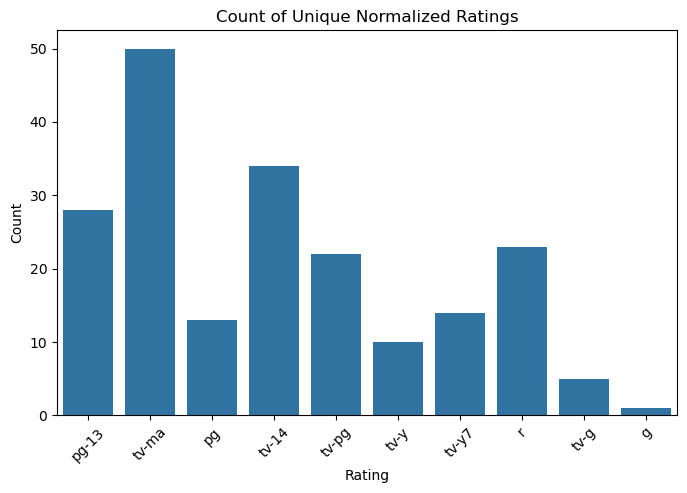

In [452]:
nt1['rating'].astype(str)
nt1['rating'].duplicated()
compare_realsedtime_and_rate = nt1.groupby('rating')[['release_year','type']]
compare_realsedtime_and_rate
compare_realsedtime_and_rate = pd.DataFrame(compare_realsedtime_and_rate)
compare_realsedtime_and_rate.astype(object)
pd.DataFrame(compare_realsedtime_and_rate)
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=nt1)
plt.title('Count of Unique Normalized Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

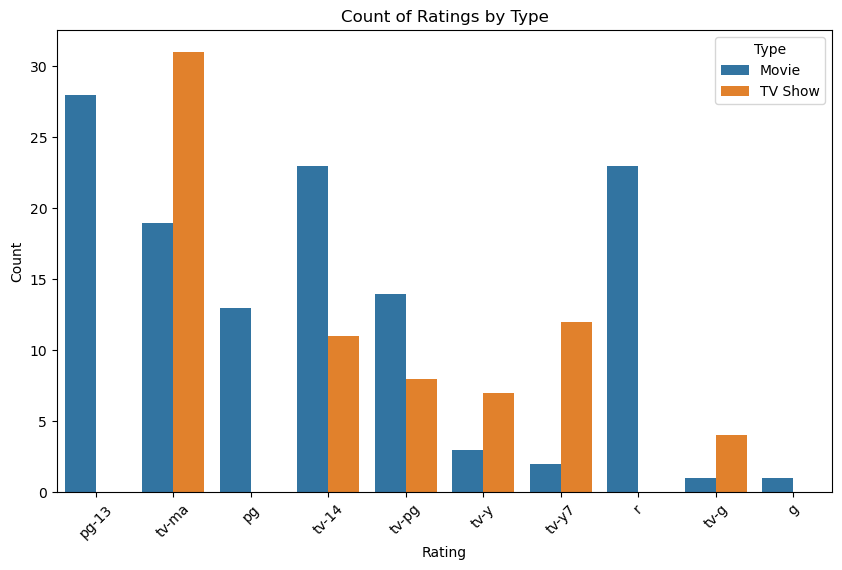

In [453]:
plt.figure(figsize=(10, 6))
sns.countplot(x='rating', hue='type', data=nt1)
plt.title('Count of Ratings by Type')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Type')
plt.show()

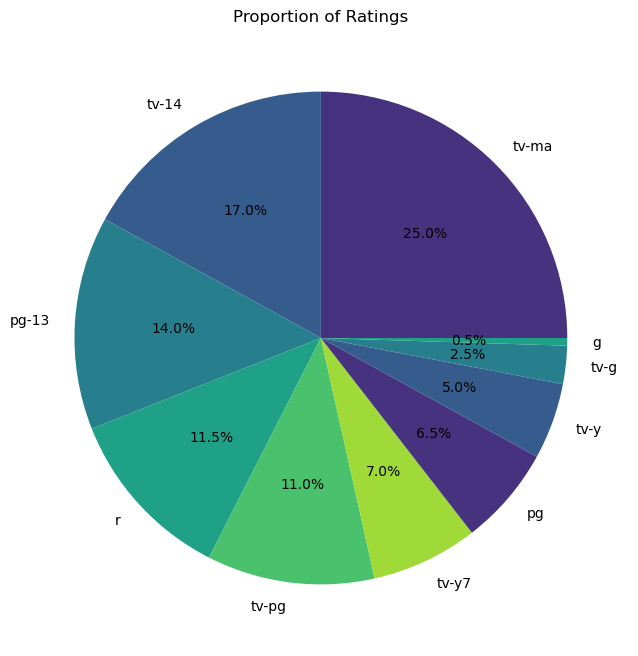

In [454]:
rating_counts = nt1['rating'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', colors=sns.color_palette('viridis'))
plt.title('Proportion of Ratings')
plt.show()

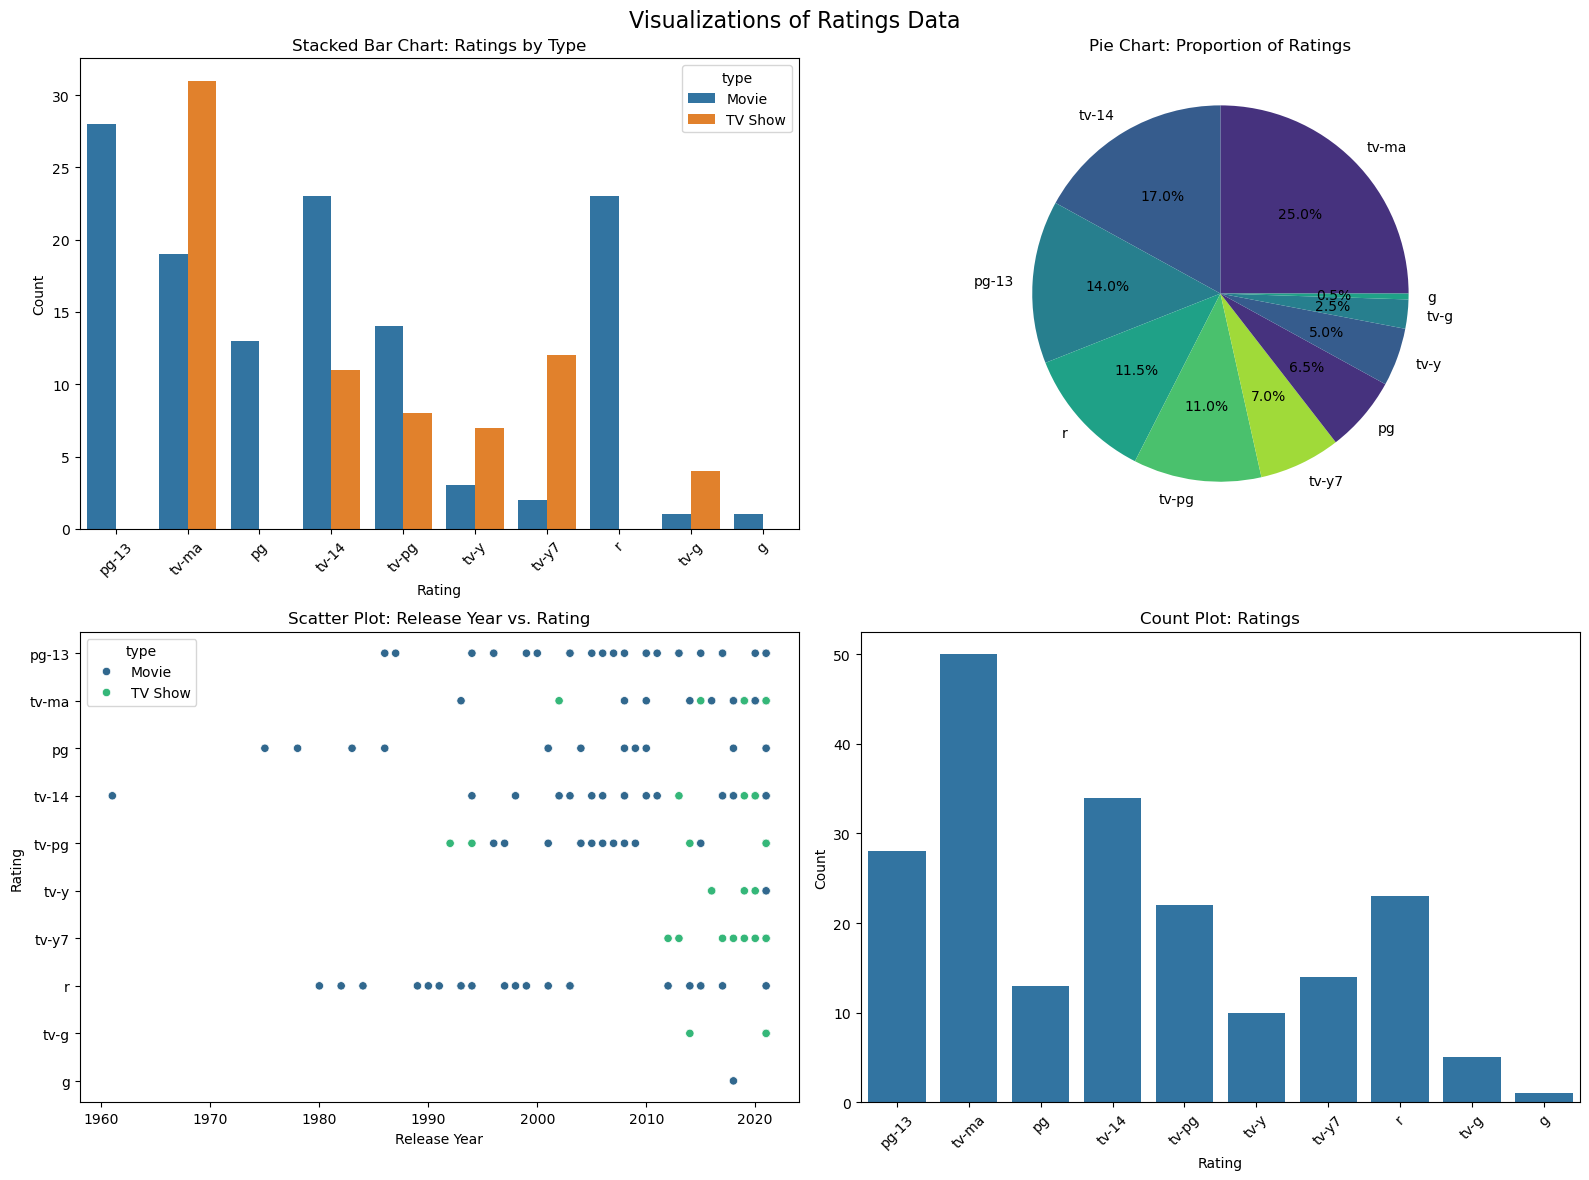

In [474]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Visualizations of Ratings Data', fontsize=16)
# Visualization 1: Stacked Bar Chart
sns.countplot(x='rating', hue='type', data=nt1, ax=axes[0, 0])
axes[0, 0].set_title('Stacked Bar Chart: Ratings by Type')
axes[0, 0].set_xlabel('Rating')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)
# Visualization 2: Pie Chart
rating_counts = nt1['rating'].value_counts()
axes[0, 1].pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', colors=sns.color_palette('viridis'))
axes[0, 1].set_title('Pie Chart: Proportion of Ratings')
# Visualization 3: Scatter Plot
sns.scatterplot(x='release_year', y='rating', hue='type', data=nt1, palette='viridis', ax=axes[1, 0])
axes[1, 0].set_title('Scatter Plot: Release Year vs. Rating')
axes[1, 0].set_xlabel('Release Year')
axes[1, 0].set_ylabel('Rating')
# Visualization 4: Count Plot
sns.countplot(x='rating', data=nt1, ax=axes[1, 1])
axes[1, 1].set_title('Count Plot: Ratings')
axes[1, 1].set_xlabel('Rating')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)
# Adjust layout and display
plt.tight_layout()
plt.show()

In [478]:
nt1.to_csv()
plt.savefig('pie_chart.png', dpi=300)

<Figure size 640x480 with 0 Axes>